In [1]:
#2.6 타이타닉 생존자 예측 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

titanic_df=pd.read_csv('./train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [2]:
print('\n ### 학습 데이터 정보 ### \n')
print(titanic_df.info())

#891개 로우. 칼럼수는 12개. 
#판다스의 object타입= string 타입 



 ### 학습 데이터 정보 ### 

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [3]:
#null 값 처리하기 
#age, cabin, embarked 칼럼은 각각 714, 204, 889개의 not null 값. -> 177, 608, 2개의 null값 
#Age 는 평균 나이, 나머지 두개는 N으로 변경 
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('N')
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('N')
print('데이터 세트 Null 값 개수', titanic_df.isnull().sum().sum())

데이터 세트 Null 값 개수 0


In [4]:
#value_counts 로 분포 알아보기 
print(' Sex 값 분포:\n', titanic_df['Sex'].value_counts())
print('\n Cabin 값 분포:\n', titanic_df['Cabin'].value_counts())
print('\n Embarked 값 분포:\n', titanic_df['Embarked'].value_counts())

#Cabin에 N이 너무많은게 이상함.. 여러개가 같이 표기된것도 존재. 앞의 알파벳이 중요하므로 추출하기 

 Sex 값 분포:
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin 값 분포:
 Cabin
N              687
G6               4
C23 C25 C27      4
B96 B98          4
F33              3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked 값 분포:
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


In [5]:
#Cabin 앞의 알파벳 한글자 추출하기 
#시리즈.str[] → Series의 각 문자열에 대해 문자 선택
titanic_df['Cabin']=titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].head(3))


0    N
1    C
2    N
Name: Cabin, dtype: str


In [6]:
#예측 수행전, 데이터 탐색 
#1. 어떤 유형의 승객이 생존 확률이 높았는지(성별, 객실 등급, 나이)
# 성별에 따른 생존자수 비교하기 
titanic_df.groupby(['Sex', 'Survived'])['Survived'].count()


Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

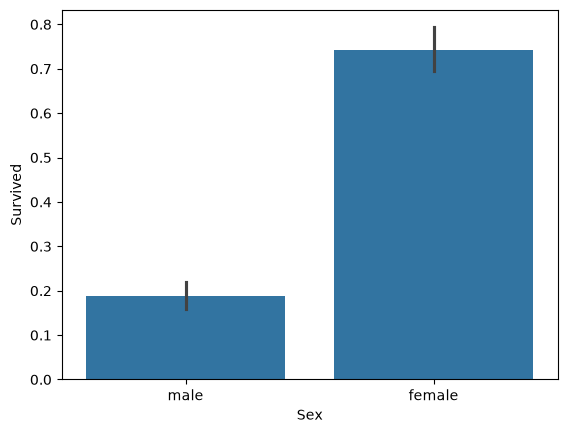

In [7]:
#시각화: Seaborn 패키지(sns) . 
sns.barplot(x='Sex', y='Survived', data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Survived'>

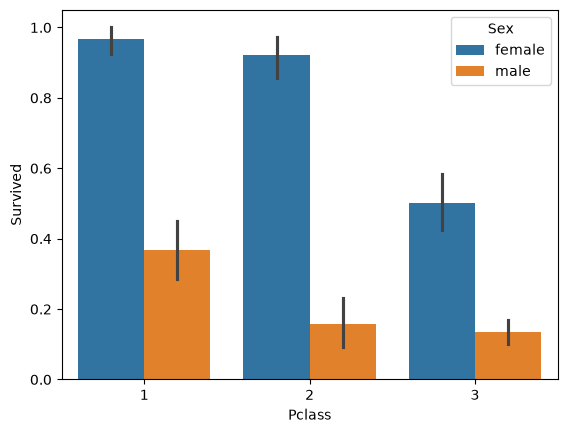

In [8]:
# 객실 등급, 성별에 따른 생존자수 비교하기 
sns.barplot(x='Pclass', y='Survived', hue='Sex',data=titanic_df)
 #hue: 막대의 색을 어떤 변수의 범주별로 나눌지 지정

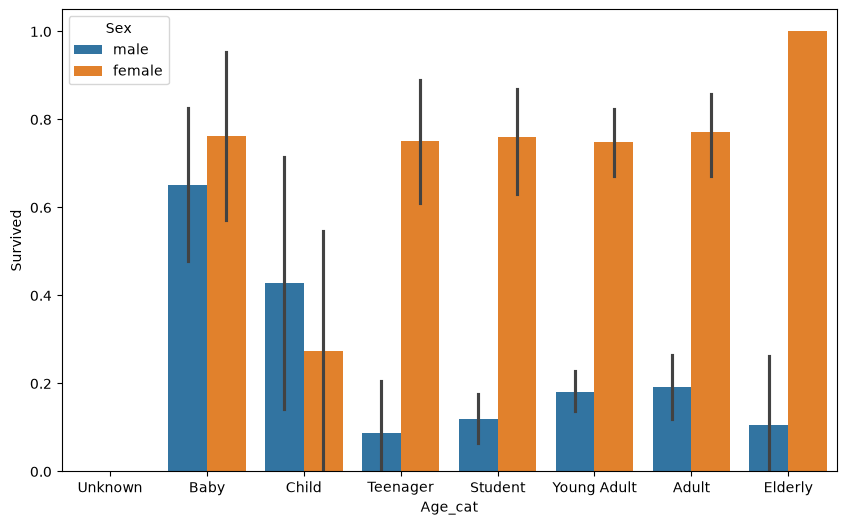

In [9]:
# Age에 따른 생존자수 비교하기 
#값 종류가 많아서, 범위별로 분류하여 카테고리값 할당. 
# -> 입력 age에 따라 구분 값을 반환하는 함수. 
def get_category(age):
    cat=''
    if age <= -1: cat = 'Unknown'
    elif age <= 5: cat = 'Baby'
    elif age <= 12: cat = 'Child'
    elif age <= 18: cat = 'Teenager'
    elif age <= 25: cat = 'Student'
    elif age <= 35: cat = 'Young Adult'
    elif age <= 60: cat = 'Adult'
    else : cat = 'Elderly'
    return cat


#막대그래프의 크기 figure을 더 크게 설정 (가로 10, 세로 5 크기의 그래프 공간 생성)
plt.figure(figsize=(10,6))  

#X축의 값을 순차적으로 표시하기 위한 설정 
group_names=['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']

#람다식에 위에서 생성한 get_category 함수를 반환값으로 지정 
titanic_df['Age_cat']=titanic_df['Age'].apply(lambda x: get_category(x))
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df, order=group_names)

titanic_df.drop('Age_cat', axis=1, inplace=True)

In [10]:
#문자열 카테고리 피처를 숫자형 카테고리 피처로 변환. 레이블 인코딩 
#여러 칼럼을 한번에 변환하는 encode_features 함수 생성. 
from sklearn.preprocessing import LabelEncoder
features=['Cabin', 'Sex', 'Embarked']
def encode_features(dataDF): #입력값: 데이터프레임명
    for feature in features:
        le=LabelEncoder()
        le=le.fit(dataDF[feature])
        dataDF[feature]=le.transform(dataDF[feature])

    return dataDF

titanic_df=encode_features(titanic_df) #인코딩한 것으로 바꿔줌 
titanic_df.head(3)



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3


In [11]:
#데이터 전처리를 전반적으로 수행하는 함수 tranform_features 만들기.
#null 처리, 불필요한 피처 제거, 인코딩 수행하는 함수를 호출하는 함수. 

 # 불필요한 피처 제거는 drop_features(df). 단순 식별자 수준인 PassengerID, Name, Ticket 피터 제거 


#1. NUll 처리 함수 
def fillna(df):
    df['Age']=df['Age'].fillna(df['Age'].mean())
    df['Cabin']=df['Cabin'].fillna('N')
    df['Embarked']=df['Embarked'].fillna('N')
    df['Fare']=df['Fare'].fillna(0) #승객이 지불한 티켓 가격 
    return df

#2. 머신러닝 알고리즘에 불필요한 피처 제거 
def drop_features(df): 
    df=df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
    return df

#3. 레이블 인코딩 수행 
def format_features(df):
    df['Cabin']=df['Cabin'].str[:1]
    features=['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le=LabelEncoder()
        le=le.fit(df[feature])
        df[feature]=le.transform(df[feature])
    
    return df
    
#앞에서 설정한 데이터 전처리 함수 모두 호출 
def transform_features(df):
    df=fillna(df)
    df=drop_features(df)
    df=format_features(df)
    return df


In [12]:
#원본 파일 다시 로딩. 피처(X) 데이터 세트, 레이블(y) 데이터 세트 추출. 
#생존여부를 예측하는 모델이므로, 레이블데이터는 Survived. 피처는 나머지. 
titanic_df=pd.read_csv('./train.csv')
X_titanic_df=titanic_df.drop('Survived', axis=1)
y_titanic_df=titanic_df['Survived']

X_titanic_df=transform_features(X_titanic_df) #전처리 


In [ ]:
#학습용데이터, 검증용데이터 분리 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X_titanic_df, y_titanic_df, test_size=0.2, random_state=11)


In [17]:
#결정트리, 랜덤포레스트, 로지스틱 회귀를 이용하여 "누가 생존할지" 생존자 예측 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#결정트리, 랜덤포레스트, 로지스틱 회귀를 위한 사이킷런 Classifier 클래스 생성 
dt_clf=DecisionTreeClassifier()
rf_clf=RandomForestClassifier()
lr_clf=LogisticRegression(solver='liblinear')

#DecisionTreeClassifier 학습/예측/평가 
dt_clf.fit(X_train, y_train)
dt_pred=dt_clf.predict(X_test)
print('DecisionTreeClassifier 정확도:{0:.4f}'.format(accuracy_score(y_test, dt_pred)))

#RandomForestClassifier 학습/예측/평가 
rf_clf.fit(X_train, y_train)
rf_pred=rf_clf.predict(X_test)
print('RandomForestClassifier 정확도:{0:.4f}'.format(accuracy_score(y_test, rf_pred)))

#LogisticRegression 학습/예측/평가 
lr_clf.fit(X_train, y_train)
lr_pred=lr_clf.predict(X_test)
print('LogisticRegression 정확도:{0:.4f}'.format(accuracy_score(y_test, lr_pred)))


DecisionTreeClassifier 정확도:0.8156
RandomForestClassifier 정확도:0.8603
LogisticRegression 정확도:0.8659


In [21]:
#교차검증도 추가해서 하기 
#1. k 폴드 (k=5)
from sklearn.model_selection import KFold

def exec_kfold(clf, folds=5):
    #폴드 세트를  5개인 Kfold 객체 생성, 폴드 수만큼 예측 결과 저장을 위한 리스트 객체 생성. 
    kfold=KFold(n_splits=folds)
    scores=[] #정확도 저장할 빈리스트 

    #Kfold 교차 검증 수행 (X_train, y_train으로.)
     #split: 학습데이터 인덱스의 1차원 array, 검증용 데이터 인덱스의 1차원 array 를 튜플로 묶어서 반환. 
    for iter_count, (train_index, test_index) in enumerate(kfold.split(X_titanic_df)):
        #X_titanic_df 데이터에서 교차 검증별로 학습과 검증데이터를 가리키는 imdex 생성. 
        X_train, X_test= X_titanic_df.values[train_index], X_titanic_df.values[test_index]
        y_train, y_test= y_titanic_df.values[train_index], y_titanic_df.values[test_index]
        # Classifier 학습, 예측, 정확도 계산 
        clf.fit(X_train, y_train)
        predictions=clf.predict(X_test)
        accuracy=accuracy_score(y_test, predictions)
        scores.append(accuracy)
        print("교치 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))


    #5개 fold 에서의 평균 정확도 계산 
    mean_score=np.mean(scores)
    print('평균 정확도:{0:.4f}'.format(mean_score))

#exec_kfold 함수 호출 
exec_kfold(dt_clf, folds=5)



#판다스에서 .values는 데이터프레임이나 시리즈의 데이터를 ndarray로 가져오는 것. 
# -> df['Age'].values: 1차원 array, df.values: 2차원 array 

교치 검증 0 정확도: 0.7598
교치 검증 1 정확도: 0.7640
교치 검증 2 정확도: 0.7865
교치 검증 3 정확도: 0.7640
교치 검증 4 정확도: 0.8427
평균 정확도:0.7834


In [23]:
#2. Stratified k 폴드 
from sklearn.model_selection import cross_val_score
#파라미터: estimator, x, y, scoring, cv /  scoring 파라미터로 지정된 성능 지표 측정값을 ndarray 로 반환.
scores=cross_val_score(dt_clf, X_titanic_df, y_titanic_df, cv=5)

for iter_count, accuracy in enumerate(scores):
    print("교차 검증 {0} 정확도 : {1:0.4f}".format(iter_count, accuracy))


print("평균 정확도: {0:.4f}".format(np.mean(scores))) 

교차 검증 0 정확도 : 0.7542
교차 검증 1 정확도 : 0.7753
교차 검증 2 정확도 : 0.8034
교차 검증 3 정확도 : 0.7753
교차 검증 4 정확도 : 0.8258
평균 정확도: 0.7868


In [ ]:
#3. GridSearchCV : 최적의 파라미터를 찾고 예측성능 측정. -> 최적 파라미터로 학습된 Estimator을 이용해 예측 수행, 예측 정확도 출력 
from sklearn.model_selection import GridSearchCV

#하이퍼파라미터는, max_depth, min_samples_split, min_samples_leaf를 변경하면서 성눙 축정
#-> 딕셔너리로 만들기. 
parameters={'max_depth':[2, 3, 5, 10], 'min_samples_split':[2,3,5], 'min_samples_leaf':[1, 5, 8]}

grid_dclf=GridSearchCV(dt_clf, param_grid=parameters, scoring='accuracy', cv=5) #모델 
grid_dclf.fit(X_train, y_train) #학습용데이터 이용. 순차적으로 학습(refit=True가 디폴트이므로 재학습까지 시킴)

print('GridSearcjCV 최적 ㅇ하이퍼 파라미터:', grid_dclf.best_params_)
print('GridSearchCV 최고 정확도:{0:.4f}'.format(grid_dclf.best_score_))
best_dclf=grid_dclf.best_estimator_

#GridSearchCV의 최적의 파라미터로 학습된 Estiamtor로 예측&평가 수행 
dpredictions=best_dclf.predict(X_test)
accuracy=accuracy_score(y_test, dpredictions)
print('테스트 세트에서의 DecisionTreeClassifier 정확도:{0:.4f}'.format(accuracy))

GridSearcjCV 최적 ㅇ하이퍼 파라미터: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV 최고 정확도:0.7992
테스트 세트에서의 DecisionTreeClassifier 정확도:0.8715


In [ ]:
#3.6 피마 인디언 당뇨병 예측 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

diabetes_data=pd.read_csv('diabetes.csv') #파일을 읽고 데이터프레임으로 불러옴 
print(diabetes_data['Outcome'].value_counts()) #0(Negative, 정상)이 상대적으로 많다ㅏ. 
diabetes_data.head(3)

Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [ ]:
#feature의 타입과 널개수
diabetes_data.info() #768개 데이터. 널값 없음. 모두 숫자형. 

#별도의 피처 인코딩은 필요하지 않아보임. 

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test , pred)
  precision = precision_score(y_test , pred)
  recall = recall_score(y_test , pred)
  f1 = f1_score(y_test,pred)
  roc_auc = roc_auc_score(y_test, pred_proba) ### 

  print('오차 행렬')
  print(confusion)

  print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1 ： {3:.4f}, AUC：{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))
  

In [ ]:
#X, y 데이터 세트 추출 
#맨 끝이 outcome 칼럼으로 레이블값임. 칼럼위치-1을 이용해 추출 
X=diabetes_data.iloc[:, :-1] 
y=diabetes_data.iloc[:, -1]

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=156, stratify=y)
#stratify=y 옵션: 데이터 분할시 y의 클래스 비율을 유지. 

#로지스틱 회귀로 학습, 예측 및 평가 수행 
lr_clf=LogisticRegression(solver='liblinear')
lr_clf.fit(X_train, y_train) #학습 
pred = lr_clf.predict(X_test) #예측
pred_proba=lr_clf.predict_proba(X_test)[:, 1] #예측: 각 데이터(각 사람)가 0(부정, 정상)일 확률, 1(긍정, 병)일 확률 얼마인지 반환
#fit에서 학습할 때, 레이블데이터세트에 0,1이 있음을 알게 됨-> predict_proba 적용시 각 행별로 0,1일 확률을 ndarray로 낸다. 
#[:, 1]: 두번째 칼럼값, 즉 1일 확률(병일 확률)

get_clf_eval(y_test, pred, pred_proba) #앞에서 만든 함수에 넣기. 

오차 행렬
[[87 13]
 [22 32]]
정확도: 0.7727, 정밀도: 0.7111, 재현율: 0.5926,    F1 ： 0.6465, AUC：0.8083


In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

def precision_recall_curve_plot(y_test, pred_proba_c1):
  # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출.
  precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)

  # X축을 threshold값으로, 우축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
  plt.figure(figsize=(8, 6))
  threshold_boundary = thresholds.shape[0]
  plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
  plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')

  # threshold 값 X 축의 Seal은을 0.1 단위로 변경
  start, end = plt.xlim()
  plt.xticks(np.round(np.arange(start, end, 0.1), 2))

  # x축, y축 label과 legend, 그리고 grid 설정
  plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
  plt.legend(); plt.grid()
  plt.show()

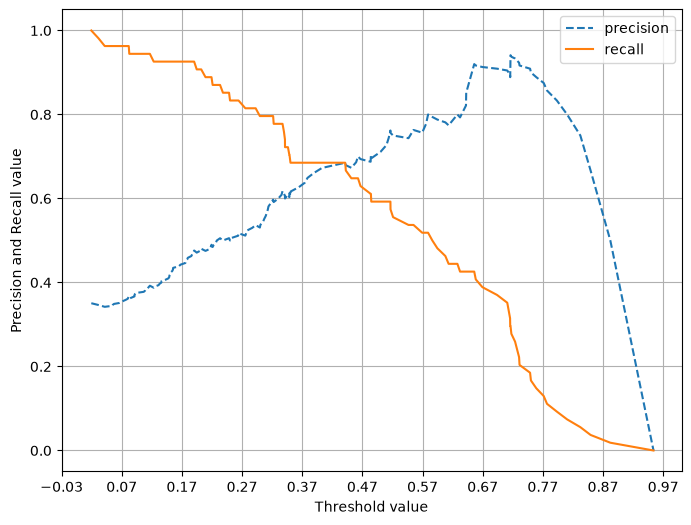

In [ ]:
#당뇨병이므로 재현율을 높이는데 초점을 더 맞춰보자. 
#정밀도 재현율 곡선을 보고 임곗값별 정밀도, 재현율의 변화 확인 : precision_recall_curve() 이용
#-> 입력값:실제 정답값, proba/ 반환값: 임곗값별 정밀도, 재현율, 임곗값 3개가 서로 다른 1차원배열로. 

pred_proba=lr_clf.predict_proba(X_test)[:, 1]
precision_recall_curve_plot(y_test, pred_proba)

#그래프를 보니, 임곗값을 0.42로 낮추면 재현율, 정밀도가 비슷해짐. but둘다 0.7도 안되게 됨. 


In [ ]:
#임곗값 조정전, 다시 데이터값 점검. 
diabetes_data.describe()

#min이 0인 피처가 상당히 많은 것을 확인가능하다. -> 말이 안됨. 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


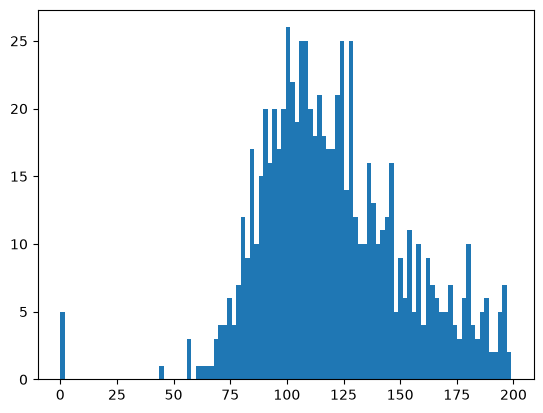

In [ ]:
plt.hist(diabetes_data['Glucose'], bins=100)
plt.show()
#0 값이 일정수준 존재함 확인. 

In [ ]:
#min()이 0인 피터에 대해 0값의 건수 및 전체 데이터 건수 대비 몇퍼센트로 존재하는지 확인 

#0값을 검사할 피처명 리스트(Pregnancies는 출산횟수이므로 제외)
zero_features=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

#전체 데이터 건수 (집계함수 이용, 아무피처로 세기)
total_count=diabetes_data['Glucose'].count() #하나의 칼럼+집계함수 

#피처별로 반복하면서 데이터값이 0인 데이터 건수 추출, 퍼센트 계산 
for feature in zero_features:
    zero_count=diabetes_data[diabetes_data[feature]==0][feature].count() #하나의 칼럼+집계함수 
    print('{0} 0건수는 {1}, 퍼센트는 {2:0.2f} %'.format(feature, zero_count, 100*zero_count/total_count))


#결과를 보니, 'SkinThickness', 'Insulin'은 0값이 매우 많음. 
#but 전체데이터 건수가 적어서 이들을 삭제하면 안됨. 평균값으로 대체필요 

Glucose 0건수는 5, 퍼센트는 0.65 %
BloodPressure 0건수는 35, 퍼센트는 4.56 %
SkinThickness 0건수는 227, 퍼센트는 29.56 %
Insulin 0건수는 374, 퍼센트는 48.70 %
BMI 0건수는 11, 퍼센트는 1.43 %


In [45]:
#피처의 0값을 평균값으로 대체 
mean_zero_features=diabetes_data[zero_features].mean() #각각의 평균을 저장. 
diabetes_data[zero_features]=diabetes_data[zero_features].replace(0, mean_zero_features)

X=diabetes_data.iloc[:, :-1] 
y=diabetes_data.iloc[:, -1]



In [66]:
#로지스틱 회귀의 경우, 숫자데이터에 스케일링 적용하는 것이 좋다. 
#스케일링 -> 학습/테스트 나누기 -> 회귀 적용 
#StandardScaler 클래스로 피처데이터 세트에 일괄적으로 스케일링(데이터 전처리중하나임) 적용 
scaler=StandardScaler()
X_scaled= scaler.fit_transform(X) #X:데이터프레임이므로 2차원 자료구조 만족-> 그대로 넣어도됨 

X_train, X_test, y_train, y_test= train_test_split(X_scaled, y, test_size=0.2, random_state=156, stratify=y)

#로지스틱 회귀로 학습,예측,평가 수행 
lr_clf=LogisticRegression()
lr_clf.fit(X_train, y_train)
pred=lr_clf.predict(X_test)
pred_proba=lr_clf.predict_proba(X_test)[:,1]

get_clf_eval(y_test, pred, pred_proba)



오차 행렬
[[90 10]
 [21 33]]
정확도: 0.7987, 정밀도: 0.7674, 재현율: 0.6111,    F1 ： 0.6804, AUC：0.8433


In [ ]:
from sklearn.preprocessing import Binarizer
def get_eval_by_threshold(y_test, pred_proba_c1, thresholds): #실제정답, 예측확률, 임계값 들어가면, 평가한거 보여주는 함수 
  # thresholds list객체 내의 값을 차례로 iteration하면서 Evaluation 수행.
  for custom_threshold in thresholds:
    binarizer = Binarizer(threshold=custom_threshold) #binarizer 모델 설정 
    custom_predict = binarizer.fit_transform(pred_proba_c1) #모델.fit_transform. 입력값은 2차원 1일확률 
    print('임곗값', custom_threshold)

    get_clf_eval(y_test, custom_predict, pred_proba_c1) #실제 정답, 예측값 , 예측확률  

#Binarixer: 1일 확률데이터(2차원)을 받으면, 임겟값을 기준으로 0,1 판단해서 내놓음 

In [ ]:
#성능수치 향상됨. but 재현율 더개선하고 싶음. 임곗값 변화시키면서 확인 
thresholds =[0.3, 0.33, 0.36, 0.39, 0.42, 0.45, 0.48, 0.50] 
pred_proba=lr_clf.predict_proba(X_test)[:,1] 
get_eval_by_threshold(y_test, pred_proba.reshape(-1, 1), thresholds) #실제 정답, 예측값 , 예측확률


임곗값 0.3
오차 행렬
[[67 33]
 [11 43]]
정확도: 0.7143, 정밀도: 0.5658, 재현율: 0.7963,    F1 ： 0.6615, AUC：0.8433
임곗값 0.33
오차 행렬
[[72 28]
 [12 42]]
정확도: 0.7403, 정밀도: 0.6000, 재현율: 0.7778,    F1 ： 0.6774, AUC：0.8433
임곗값 0.36
오차 행렬
[[76 24]
 [15 39]]
정확도: 0.7468, 정밀도: 0.6190, 재현율: 0.7222,    F1 ： 0.6667, AUC：0.8433
임곗값 0.39
오차 행렬
[[78 22]
 [16 38]]
정확도: 0.7532, 정밀도: 0.6333, 재현율: 0.7037,    F1 ： 0.6667, AUC：0.8433
임곗값 0.42
오차 행렬
[[84 16]
 [18 36]]
정확도: 0.7792, 정밀도: 0.6923, 재현율: 0.6667,    F1 ： 0.6792, AUC：0.8433
임곗값 0.45
오차 행렬
[[85 15]
 [18 36]]
정확도: 0.7857, 정밀도: 0.7059, 재현율: 0.6667,    F1 ： 0.6857, AUC：0.8433
임곗값 0.48
오차 행렬
[[88 12]
 [19 35]]
정확도: 0.7987, 정밀도: 0.7447, 재현율: 0.6481,    F1 ： 0.6931, AUC：0.8433
임곗값 0.5
오차 행렬
[[90 10]
 [21 33]]
정확도: 0.7987, 정밀도: 0.7674, 재현율: 0.6111,    F1 ： 0.6804, AUC：0.8433


In [60]:
#임곗값을 0.48로 설정한 Binarizer 생성 
binarizer =Binarizer(threshold=0.48)

#위에서 구한 lr_clf의 predict_proba() 예측 확률 array에서 1에 해당하는 칼럼값을 Binarizer로 변환 
 
pred_th_048=binarizer.fit_transform(pred_proba.reshape(-1, 1))
get_clf_eval(y_test, pred_th_048, pred_proba)

오차 행렬
[[88 12]
 [19 35]]
정확도: 0.7987, 정밀도: 0.7447, 재현율: 0.6481,    F1 ： 0.6931, AUC：0.8433
